# Notebook 2: 运动分类器训练

训练轻量级分类器, 对每个波比跳窗口生成简单运动类型的概率分布。

**分类器**: Random Forest, KNN, Cosine Similarity Prototype

**关键验证**: 波比跳分布随时间变化的热力图。

In [ ]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import pickle
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder, normalize

PROJECT_ROOT = Path(r"D:\data\PPG_HeartRate\Algorithm\outline-PPGtoHR")
ARTIFACTS_DIR = PROJECT_ROOT / "docs" / "research" / "artifacts"

sns.set_style("whitegrid")
plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

EXERCISES = {
    "jump_rope": {"label": "跳绳"},
    "arm_curl": {"label": "手臂弯举"},
    "push_up": {"label": "俯卧撑"},
    "jumping_jack": {"label": "开合跳"},
    "burpee": {"label": "波比跳"},
}

## 1. 加载特征数据

In [2]:
with open(ARTIFACTS_DIR / "mimu_features_all.pkl", "rb") as f:
    data = pickle.load(f)

X = data["X"]
y = data["y"]
df = data["df"]
FEATURE_NAMES = data["feature_names"]

print(f"特征矩阵: {X.shape}")
print(f"运动类型: {np.unique(y)}")

特征矩阵: (2051, 75)
运动类型: ['arm_curl' 'burpee' 'jump_rope' 'jumping_jack' 'push_up']


## 2. 数据划分与预处理

- 训练集: 仅简单运动的**运动段**窗口（静息段跨所有运动类型特征相似，无区分度）
- 波比跳: 全部窗口用于推理（含静息段，分类器输出对应低置信度）
- StandardScaler 标准化 + LabelEncoder 编码

In [3]:
# 仅使用简单运动的运动段窗口训练分类器
# 静息段在所有运动类型中特征高度相似 (acc_mag_std < 0.05)，不提供类别区分信息
simple_mask = df["exercise"].values != "burpee"
motion_mask = df["is_motion"].values
train_mask = simple_mask & motion_mask  # 简单运动 + 运动段
burpee_mask = ~simple_mask

X_train_all = X[train_mask]
y_train_all = y[train_mask]
files_train_all = df["file_name"].values[train_mask]

X_burpee = X[burpee_mask]
y_burpee = y[burpee_mask]
burpee_times = df["window_time"].values[burpee_mask]
burpee_files = df["file_name"].values[burpee_mask]

n_rest_dropped = simple_mask.sum() - train_mask.sum()
print(f"简单运动总窗口: {simple_mask.sum()}, 运动段: {train_mask.sum()}, 剔除静息: {n_rest_dropped}")
print(f"训练集 (简单运动运动段): {X_train_all.shape[0]} 个窗口")
print(f"推理集 (波比跳全部窗口): {X_burpee.shape[0]} 个窗口")
print(f"训练集类别: {dict(zip(*np.unique(y_train_all, return_counts=True)))}")

# 标准化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_all)
X_burpee_scaled = scaler.transform(X_burpee)

# 标签编码
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train_all)
print(f"\n类别映射: {dict(zip(le.classes_, le.transform(le.classes_)))}")
SIMPLE_CLASSES = list(le.classes_)
print(f"简单运动类别: {SIMPLE_CLASSES}")

简单运动总窗口: 1616, 运动段: 432, 剔除静息: 1184
训练集 (简单运动运动段): 432 个窗口
推理集 (波比跳全部窗口): 435 个窗口
训练集类别: {'arm_curl': np.int64(131), 'jump_rope': np.int64(120), 'jumping_jack': np.int64(132), 'push_up': np.int64(49)}

类别映射: {'arm_curl': np.int64(0), 'jump_rope': np.int64(1), 'jumping_jack': np.int64(2), 'push_up': np.int64(3)}
简单运动类别: ['arm_curl', 'jump_rope', 'jumping_jack', 'push_up']


## 3. 分类器训练与评估

P1 修复: 使用 **GroupKFold（按文件名分组）** 替代 StratifiedKFold，
避免重叠窗口 (8s/1s 步长) 导致的数据泄漏。

In [4]:
from sklearn.model_selection import GroupKFold

# P1: GroupKFold 按文件名分组, 避免同一文件的重叠窗口同时出现在训练集和验证集
groups_train = files_train_all  # file_name 作为分组键
n_groups = len(np.unique(groups_train))
n_splits = min(5, n_groups)

gkf = GroupKFold(n_splits=n_splits)

rf = RandomForestClassifier(
    n_estimators=100, max_depth=10, min_samples_leaf=5,
    class_weight="balanced", random_state=42,
)
rf_scores = cross_val_score(rf, X_train_scaled, y_train_encoded,
                            cv=gkf, groups=groups_train, scoring="accuracy")
print(f"RandomForest GroupKFold({n_splits}) accuracy: {rf_scores.mean():.3f} +/- {rf_scores.std():.3f}")

knn = KNeighborsClassifier(n_neighbors=5)
knn_scores = cross_val_score(knn, X_train_scaled, y_train_encoded,
                             cv=gkf, groups=groups_train, scoring="accuracy")
print(f"KNN GroupKFold({n_splits}) accuracy: {knn_scores.mean():.3f} +/- {knn_scores.std():.3f}")

RandomForest GroupKFold(5) accuracy: 0.780 +/- 0.390


d:\Anaconda\envs\ppg-hr\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


KNN GroupKFold(5) accuracy: 0.775 +/- 0.388


## 4. 余弦相似度质心分类器

计算每个简单运动类别的均值特征向量 (质心), 对波比跳窗口计算与各质心的余弦相似度,
通过 softmax 归一化得到概率分布, 并与 RF/KNN 结果对比。

In [5]:
def cosine_prototype_predict_proba(X_train, y_train, X_test, classes):
    """Cosine similarity prototype classifier.

    对每个类别计算质心 (均值特征向量), 然后对测试样本计算
    与各质心的余弦相似度, 通过 softmax 归一化为概率分布。
    """
    centroids = np.array([X_train[y_train == c].mean(axis=0) for c in range(len(classes))])
    centroids_norm = normalize(centroids)
    X_test_norm = normalize(X_test)
    similarities = X_test_norm @ centroids_norm.T  # (T, N)
    # softmax
    exp_sim = np.exp(similarities - similarities.max(axis=1, keepdims=True))
    proba = exp_sim / exp_sim.sum(axis=1, keepdims=True)
    return proba


# 在波比跳窗口上计算余弦相似度概率
cosine_proba = cosine_prototype_predict_proba(
    X_train_scaled, y_train_encoded, X_burpee_scaled, SIMPLE_CLASSES,
)

# 同时获取 RF 和 KNN 的概率用于对比
rf.fit(X_train_scaled, y_train_encoded)
knn.fit(X_train_scaled, y_train_encoded)
rf_proba = rf.predict_proba(X_burpee_scaled)
knn_proba = knn.predict_proba(X_burpee_scaled)

# 对比三种分类器的预测一致性
rf_pred = np.array([SIMPLE_CLASSES[i] for i in rf_proba.argmax(axis=1)])
knn_pred = np.array([SIMPLE_CLASSES[i] for i in knn_proba.argmax(axis=1)])
cosine_pred = np.array([SIMPLE_CLASSES[i] for i in cosine_proba.argmax(axis=1)])

rf_knn_agree = np.mean(rf_pred == knn_pred)
rf_cosine_agree = np.mean(rf_pred == cosine_pred)
knn_cosine_agree = np.mean(knn_pred == cosine_pred)

print("三种分类器在波比跳窗口上的预测一致性:")
print(f"  RF  vs KNN:    {rf_knn_agree:.3f}")
print(f"  RF  vs Cosine: {rf_cosine_agree:.3f}")
print(f"  KNN vs Cosine: {knn_cosine_agree:.3f}")

# 各分类器主要预测类别分布
from collections import Counter
for name, preds in [("RF", rf_pred), ("KNN", knn_pred), ("Cosine", cosine_pred)]:
    cnt = Counter(preds)
    dist = ", ".join(f"{EXERCISES[k]['label']}: {v}" for k, v in sorted(cnt.items()))
    print(f"  {name}: {dist}")

三种分类器在波比跳窗口上的预测一致性:
  RF  vs KNN:    0.823
  RF  vs Cosine: 0.743
  KNN vs Cosine: 0.759
  RF: 手臂弯举: 3, 开合跳: 114, 俯卧撑: 318
  KNN: 跳绳: 72, 开合跳: 114, 俯卧撑: 249
  Cosine: 跳绳: 50, 开合跳: 55, 俯卧撑: 330


RandomForest 训练集分类报告:
              precision    recall  f1-score   support

    arm_curl       1.00      1.00      1.00       131
   jump_rope       1.00      0.99      1.00       120
jumping_jack       1.00      0.98      0.99       132
     push_up       0.94      1.00      0.97        49

    accuracy                           0.99       432
   macro avg       0.99      0.99      0.99       432
weighted avg       0.99      0.99      0.99       432



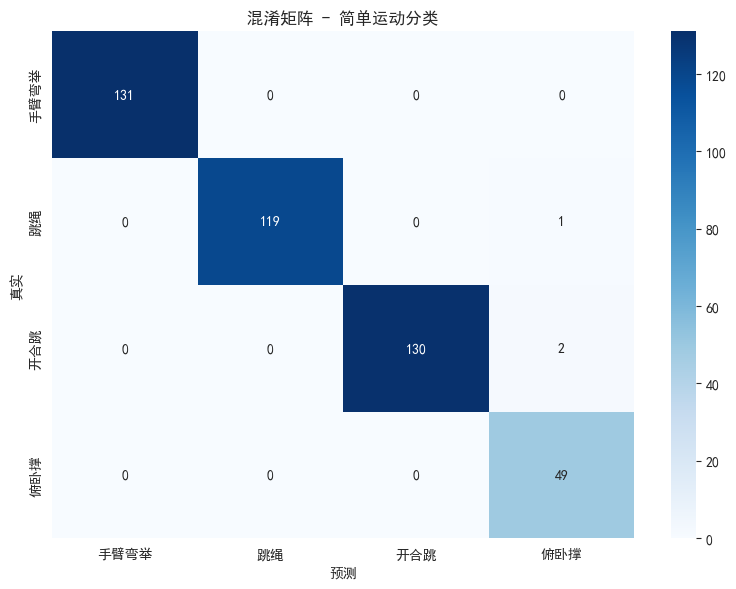

In [6]:
# RF 最终训练结果 + 分类报告 + 混淆矩阵
y_pred = rf.predict(X_train_scaled)
print("RandomForest 训练集分类报告:")
print(classification_report(y_train_encoded, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_train_encoded, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[EXERCISES[c]["label"] for c in le.classes_],
            yticklabels=[EXERCISES[c]["label"] for c in le.classes_],
            ax=ax)
ax.set_xlabel("预测")
ax.set_ylabel("真实")
ax.set_title("混淆矩阵 - 简单运动分类")
plt.tight_layout()
plt.show()

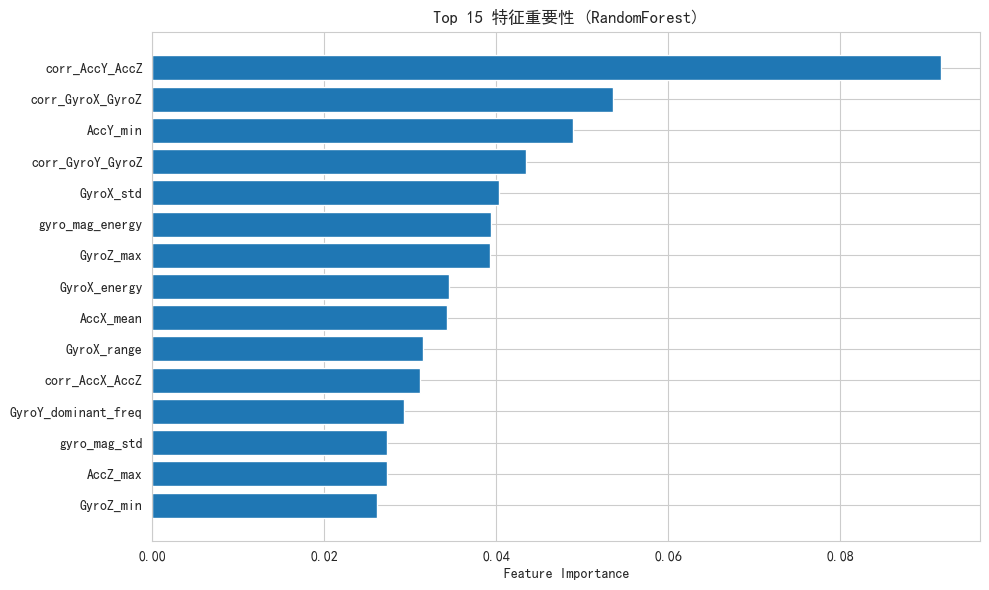

In [7]:
# 特征重要性
importances = rf.feature_importances_
top_k = 15
top_idx = np.argsort(importances)[-top_k:]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(top_k), importances[top_idx])
ax.set_yticks(range(top_k))
ax.set_yticklabels([FEATURE_NAMES[i] for i in top_idx])
ax.set_xlabel("Feature Importance")
ax.set_title(f"Top {top_k} 特征重要性 (RandomForest)")
plt.tight_layout()
plt.show()

## 5. 波比跳窗口分布推理

In [8]:
# RF predict_proba 在波比跳上的推理结果
burpee_proba = rf.predict_proba(X_burpee_scaled)

print(f"波比跳概率分布矩阵: {burpee_proba.shape}")
print(f"类别对应: {list(zip(le.classes_, range(len(le.classes_))))}")
print(f"\n各窗口最大概率: mean={burpee_proba.max(axis=1).mean():.3f}, "
      f"min={burpee_proba.max(axis=1).min():.3f}, max={burpee_proba.max(axis=1).max():.3f}")

波比跳概率分布矩阵: (435, 4)
类别对应: [('arm_curl', 0), ('jump_rope', 1), ('jumping_jack', 2), ('push_up', 3)]

各窗口最大概率: mean=0.684, min=0.360, max=0.854


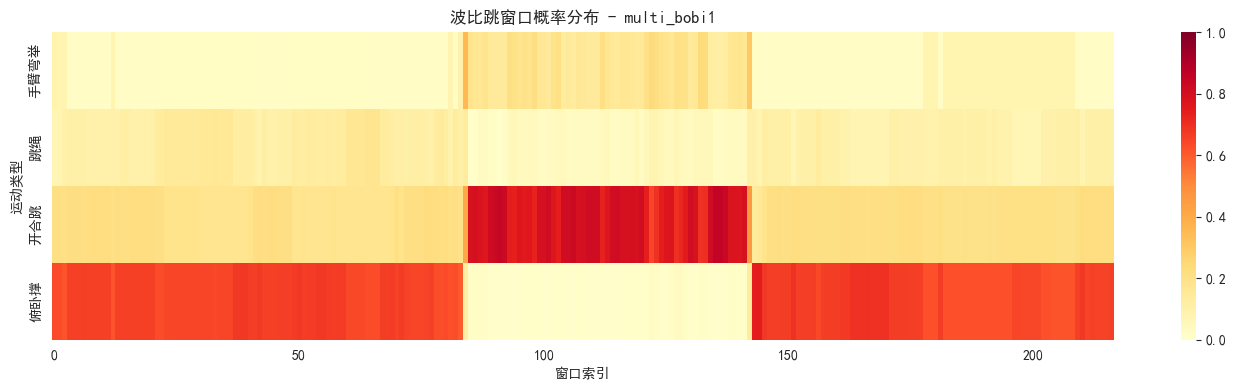

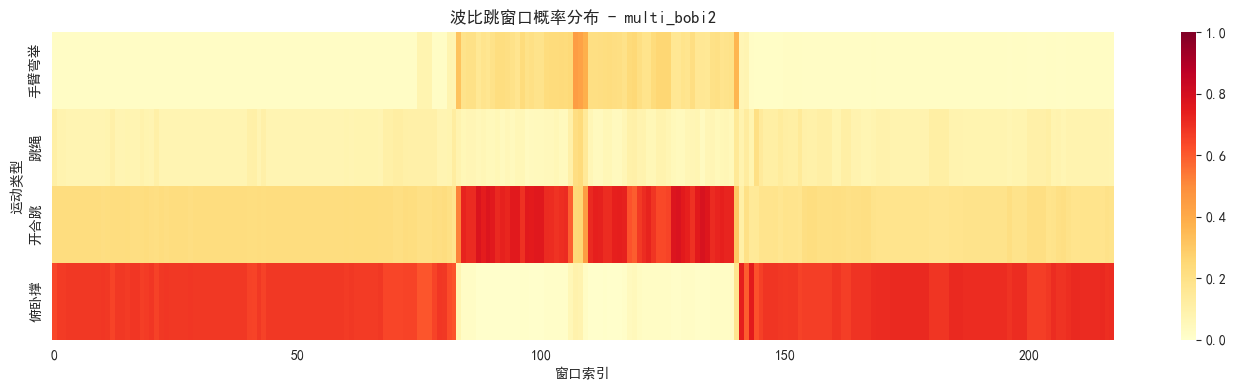

In [9]:
# 热力图: 每个波比跳文件的概率分布
unique_burpee_files = np.unique(burpee_files)

for bf in unique_burpee_files:
    file_mask = burpee_files == bf
    proba_file = burpee_proba[file_mask]
    times_file = burpee_times[file_mask]

    fig, ax = plt.subplots(figsize=(14, 4))
    sns.heatmap(
        proba_file.T,
        xticklabels=50,
        yticklabels=[EXERCISES[c]["label"] for c in le.classes_],
        cmap="YlOrRd", vmin=0, vmax=1, ax=ax,
    )
    ax.set_xlabel("窗口索引")
    ax.set_ylabel("运动类型")
    ax.set_title(f"波比跳窗口概率分布 - {bf}")
    plt.tight_layout()
    plt.show()

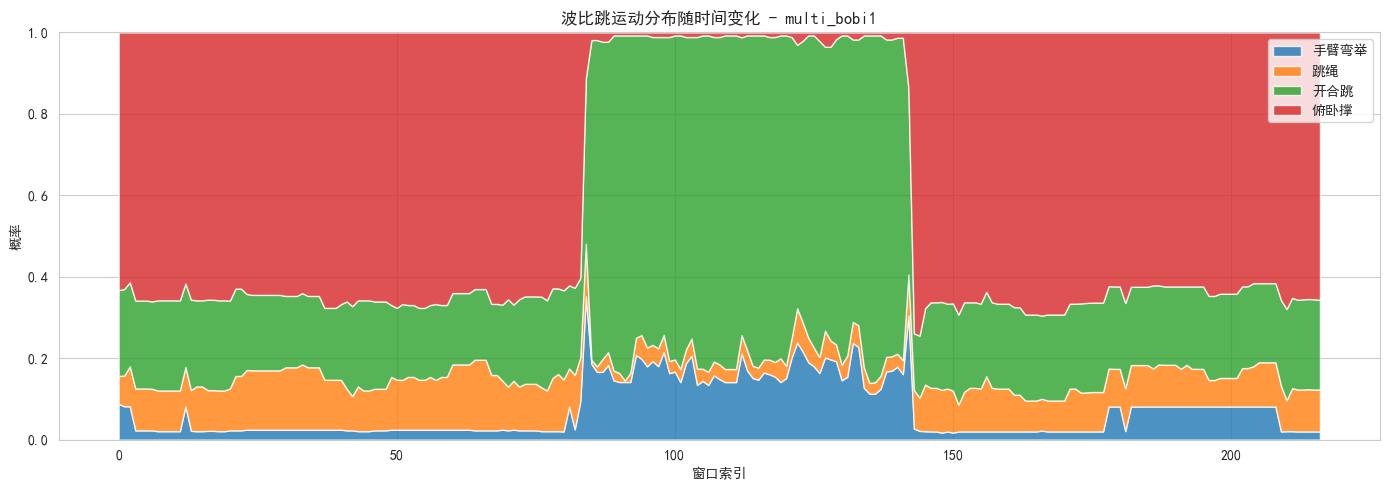

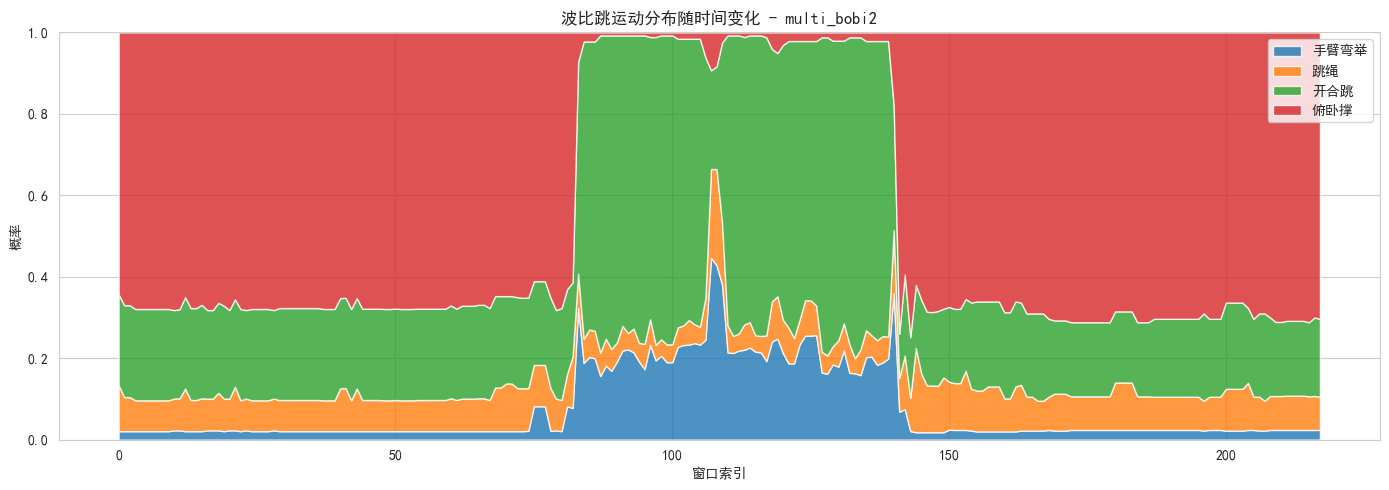

In [10]:
# 堆叠面积图: 每个波比跳文件的概率随时间变化
for bf in unique_burpee_files:
    file_mask = burpee_files == bf
    proba_file = burpee_proba[file_mask]
    times_file = burpee_times[file_mask]

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.stackplot(
        range(len(times_file)),
        *[proba_file[:, i] for i in range(proba_file.shape[1])],
        labels=[EXERCISES[c]["label"] for c in le.classes_],
        alpha=0.8,
    )
    ax.set_xlabel("窗口索引")
    ax.set_ylabel("概率")
    ax.set_title(f"波比跳运动分布随时间变化 - {bf}")
    ax.legend(loc="upper right")
    ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.show()

## 6. 保存

In [11]:
import joblib

np.save(ARTIFACTS_DIR / "burpee_window_distributions.npy", burpee_proba)
joblib.dump({"model": rf, "scaler": scaler, "label_encoder": le},
            ARTIFACTS_DIR / "classifier_model.pkl")

burpee_meta = {
    "times": burpee_times,
    "files": burpee_files,
    "class_names": SIMPLE_CLASSES,
}
with open(ARTIFACTS_DIR / "burpee_meta.pkl", "wb") as f:
    pickle.dump(burpee_meta, f)

print("已保存:")
print(f"  burpee_window_distributions.npy: shape={burpee_proba.shape}")
print(f"  classifier_model.pkl")
print(f"  burpee_meta.pkl")

已保存:
  burpee_window_distributions.npy: shape=(435, 4)
  classifier_model.pkl
  burpee_meta.pkl
